In [57]:
import pandas as pd

df=pd.read_csv("cleaned_stock_data.csv")
df = df.sort_values(['Date', 'Company'])

In [58]:
df.head()

,Company,Open,High,Low,Close,Adj_Close,Volume,Dividends,Stock_Splits,Date,Return
0,AAPL,0.129464,0.130022,0.126674,0.127790,0.098057,137737600,0.0,0.0,1985-02-01,-0.012930
21385,ADI,3.359375,3.359375,3.218750,3.218750,1.979877,577600,0.0,0.0,1985-02-01,-0.041860
31655,ADP,2.180926,2.193318,2.156143,2.187122,1.083401,1319439,0.0,0.0,1985-02-01,0.000000
52092,AEP,21.375000,21.625000,21.250000,21.500000,2.376553,335200,0.0,0.0,1985-02-01,0.005848
62362,AMAT,0.273438,0.273438,0.269531,0.271484,0.197045,8012800,0.0,0.0,1985-02-01,-0.007146


In [59]:
returns.index = pd.to_datetime(returns.index)
adj_dates = pd.to_datetime(adj_dates)


In [60]:

returns = df.pivot(index='Date', columns='Company', values='Return')


returns = returns.dropna(how='all')

returns.head()
print(returns.shape)

(10270, 102)


In [61]:
import numpy as np

WINDOW = 60   # rolling window in trading days
STEP   = 5    # compute every 5 days

def rolling_corr_matrices(returns_df, window=60, step=5):
    dates = []
    corr_mats = []
    
    for i in range(window, len(returns_df), step):
        window_data = returns_df.iloc[i-window:i]
        C = window_data.corr()
        dates.append(returns_df.index[i-1])  # end date of window
        corr_mats.append(C)
    
    return dates, corr_mats

corr_dates, corr_mats = rolling_corr_matrices(returns, window=WINDOW, step=STEP)

len(corr_dates), len(corr_mats)

(2042, 2042)

In [62]:
corr_mats[0].head()

Company,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,AMAT,AMD,AMGN,...,TSLA,TTD,TTWO,TXN,VRSK,VRTX,WBD,WDAY,XEL,ZS
Company,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,NaN,NaN,0.020364,0.125236,NaN,0.079712,0.111292,0.086655,-0.060103,...,NaN,NaN,NaN,0.022053,NaN,NaN,NaN,NaN,0.226652,NaN
ABNB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADI,0.020364,NaN,NaN,1.000000,0.085398,NaN,-0.077302,0.241212,0.165370,-0.123304,...,NaN,NaN,NaN,0.039788,NaN,NaN,NaN,NaN,0.055480,NaN
ADP,0.125236,NaN,NaN,0.085398,1.000000,NaN,0.233484,0.255415,0.398103,-0.060434,...,NaN,NaN,NaN,0.344180,NaN,NaN,NaN,NaN,0.056362,NaN


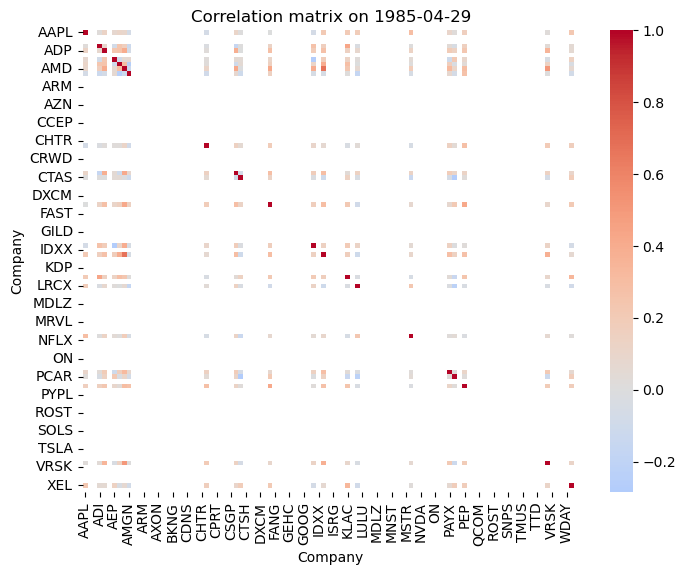

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_dates = pd.to_datetime(corr_dates)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mats[0], cmap='coolwarm', center=0)
plt.title(f"Correlation matrix on {corr_dates[0].date()}")
plt.show()


In [64]:
THRESHOLD = 0.3  # you can tune this

adj_dates = []
adj_mats = []

for date, C in zip(corr_dates, corr_mats):
    C = C.fillna(0).clip(-1, 1)
    W = C.where(C > THRESHOLD, 0.0)  # keep only correlations > threshold
    # zero diagonal (no self-loops)
    for col in W.columns:
        W.loc[col, col] = 0.0
    
    adj_dates.append(date)
    adj_mats.append(W)

len(adj_mats)

2042

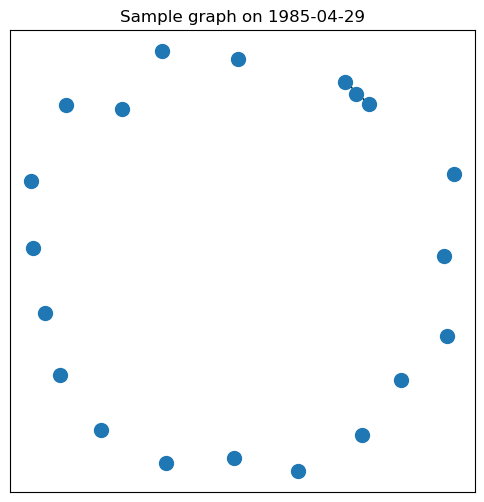

In [65]:
import networkx as nx

W0 = adj_mats[0]
G0 = nx.from_pandas_adjacency(W0)

# maybe only visualize a small subset of nodes to avoid clutter
sub_nodes = list(W0.columns[:20])
G_sub = G0.subgraph(sub_nodes)
corr_dates = pd.to_datetime(corr_dates)
adj_dates  = pd.to_datetime(adj_dates)

plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G_sub, seed=42)
nx.draw_networkx(G_sub, pos=pos, node_size=100, with_labels=False)
plt.title(f"Sample graph on {adj_dates[0].date()}")
plt.show()


In [69]:
def laplacian_from_W(W_df):
    """
    W_df: pandas DataFrame, adjacency matrix (symmetric, non-negative)
    """
    W = W_df.values
    d = W.sum(axis=1)
    D = np.diag(d)
    L = D - W
    return L

def diffusion_residuals(W_df, r, alpha=0.1):
    """
    W_df: adjacency matrix DataFrame (tickers x tickers)
    r: numpy array of size n (signal on nodes, in same order as W_df.index)
    alpha: diffusion step size
    """
    L = laplacian_from_W(W_df)
    # one-step diffusion
    r_smooth = r - alpha * L.dot(r)
    epsilon = r - r_smooth
    return epsilon

In [73]:
RECENT_WINDOW = 5
ALPHA = 0.1
# FIX TYPES
returns.index = pd.to_datetime(returns.index)
adj_dates = pd.to_datetime(adj_dates)

mispricing_series_list = []

for date, W_df in zip(adj_dates, adj_mats):

    if date not in returns.index:
        continue

    t_idx = returns.index.get_loc(date)
    if t_idx < RECENT_WINDOW:
        continue

    window_data = returns.iloc[t_idx-RECENT_WINDOW+1:t_idx+1]
    r = window_data.sum()
    r = r.reindex(W_df.index)

    if r.isna().all():
        continue

    epsilon = diffusion_residuals(W_df, r.values, alpha=ALPHA)

    eps_series = pd.Series(epsilon, index=W_df.index, name=date)
    mispricing_series_list.append(eps_series)

mispricing_df = pd.DataFrame(mispricing_series_list)
mispricing_df.index.name = 'date'


mispricing_df.to_csv("mispricing_residuals.csv")

mispricing_df.head()

Company,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,AMAT,AMD,AMGN,...,TSLA,TTD,TTWO,TXN,VRSK,VRTX,WBD,WDAY,XEL,ZS
date,,,,,,,,,,,,,,,,,,,,,
1985-04-29,0.0,0.0,0.0,-0.004902,-0.001646,0.0,0.000000,-0.003722,-0.015179,0.000000,...,0.0,0.0,0.0,0.005337,0.0,0.0,0.0,0.0,-0.000616,0.0
1985-05-06,0.0,0.0,0.0,0.000561,0.004929,0.0,0.000346,0.003117,-0.005888,0.000000,...,0.0,0.0,0.0,0.000766,0.0,0.0,0.0,0.0,-0.000908,0.0
1985-05-13,0.0,0.0,0.0,0.001870,-0.005246,0.0,0.000271,0.004637,0.006534,-0.000117,...,0.0,0.0,0.0,-0.005069,0.0,0.0,0.0,0.0,-0.003416,0.0
1985-05-20,0.0,0.0,0.0,-0.001999,-0.003337,0.0,0.002042,0.015184,0.003495,0.006196,...,0.0,0.0,0.0,-0.005136,0.0,0.0,0.0,0.0,-0.000580,0.0
1985-05-28,0.0,0.0,0.0,0.001597,0.005258,0.0,0.002386,-0.006599,-0.001976,-0.000942,...,0.0,0.0,0.0,-0.000769,0.0,0.0,0.0,0.0,0.000442,0.0


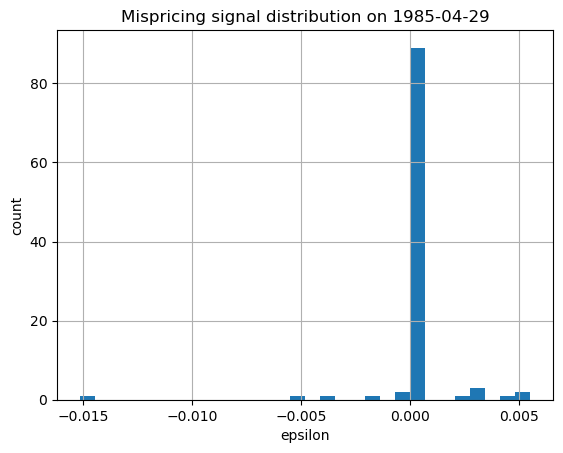

In [75]:
sample_date = mispricing_df.index[0]
mispricing_df.loc[sample_date].hist(bins=30)
plt.title(f"Mispricing signal distribution on {sample_date.date()}")
plt.xlabel("epsilon")
plt.ylabel("count")
plt.show()

Correlation between diffusion residuals and future returns: -0.033188127866975815


/var/folders/hl/vccl5tsj2_1gxks1lv3sm2hr0000gn/T/ipykernel_1936/1271950740.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  future_ret = prices.pct_change(periods=H).shift(-H)


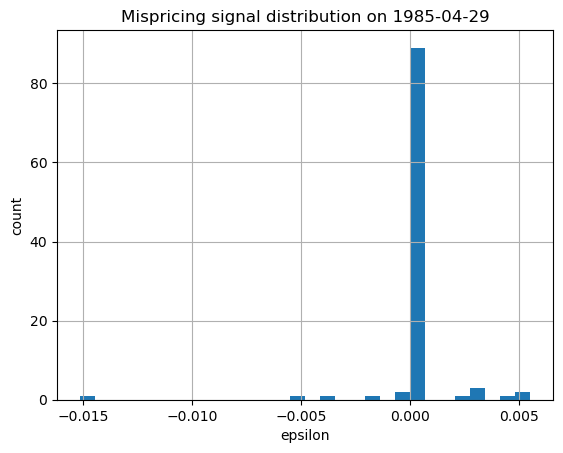

In [83]:
H = 5  # 5-day forward return

# --- Pivot prices ---
prices = df.pivot(index='Date', columns='Company', values='Adj_Close')

# --- Ensure indices are datetime ---
prices.index = pd.to_datetime(prices.index)
returns.index = pd.to_datetime(returns.index)
mispricing_df.index = pd.to_datetime(mispricing_df.index)

# --- Align start dates safely ---
common_dates = prices.index.intersection(returns.index)
prices = prices.loc[common_dates]

# --- Compute H-day forward returns ---
future_ret = prices.pct_change(periods=H).shift(-H)

# --- Align with mispricing residuals ---
common_dates = mispricing_df.index.intersection(future_ret.index)
eps_today = mispricing_df.loc[common_dates]
ret_next = future_ret.loc[common_dates]

# --- Flatten arrays for correlation ---
eps_flat = eps_today.values.flatten()
ret_flat = ret_next.values.flatten()

# --- Remove NaNs ---
mask = ~np.isnan(eps_flat) & ~np.isnan(ret_flat)
eps_flat = eps_flat[mask]
ret_flat = ret_flat[mask]

# --- Compute correlation ---
corr = np.corrcoef(eps_flat, ret_flat)[0, 1]
print("Correlation between diffusion residuals and future returns:", corr)

# --- Optional: visualize distribution for the first date ---
if len(common_dates) > 0:
    sample_date = common_dates[0]
    eps_today.loc[sample_date].hist(bins=30)
    plt.title(f"Mispricing signal distribution on {sample_date.date()}")
    plt.xlabel("epsilon")
    plt.ylabel("count")
    plt.show()
